In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
set_seed(0) 

## Loading a trained model
All models trained on the default versions of the catalog are stored in `{PROJECT_ROOT_DIR}/trained_models/`.

In [25]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/rtpp_20250820-153247") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)

model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 32, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20250820-153247', 'cuda_id': 0, 'dataset': 'AZDX', 'seed': 0, 'minibatch_training': True, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.12284710258245468, 'tau_min': 0.0010000000474974513, 'tau_max': 6.258999824523926, 'tau_q05': 0.07999999821186066, 'tau_q025': 0.009999999776482582, 'mag_mean': 4.849750995635986, 'time_max': 10000.0, 'time_mean': 

OptimizedModule(
  (_orig_mod): RecurrentTPP(
    (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
    (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
    (rnn): GRU(2, 32, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

## Loading the catalog
We load the catalog like in the previous notebook.

In [26]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/AZDX/raw.


In [27]:
catalog_ds.full_sequence

Sequence(
  inter_times: [136453],
  arrival_times: [136452],
  t_start: 0.0,
  t_end: 19886.0,
  t_nll_start: 0.0,
  mag: [136452],
  loc: [136452, 2],
  depth: [136452]
)

In [28]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()

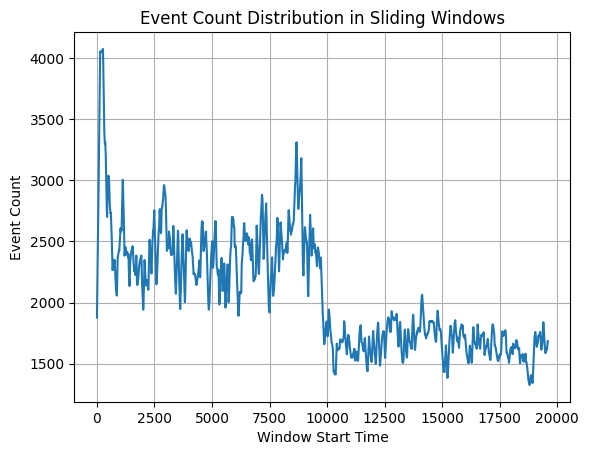

In [29]:
import matplotlib.pyplot as plt

plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [8]:
b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)

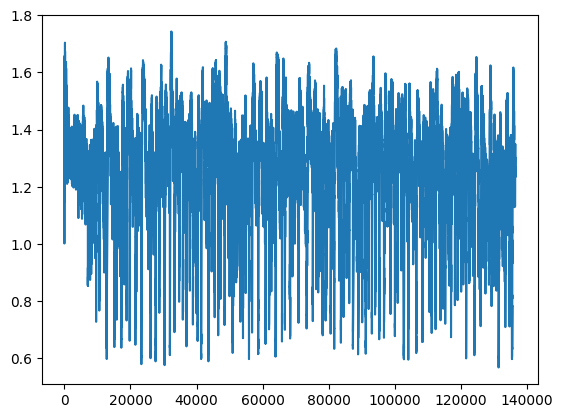

In [9]:
plt.plot(b_seq.squeeze().detach().cpu().numpy())
plt.savefig(checkpoint_dir/'b_pred.png')

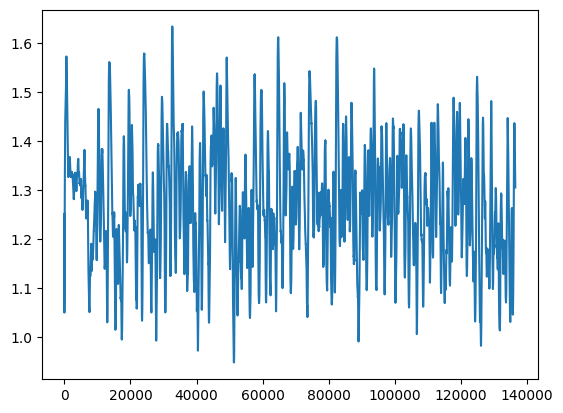

In [10]:
import pandas as pd

data = b_seq.squeeze().detach().cpu().numpy()
smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()

plt.plot(smooth)
plt.savefig(checkpoint_dir/'b_pred_smooth.png')


## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

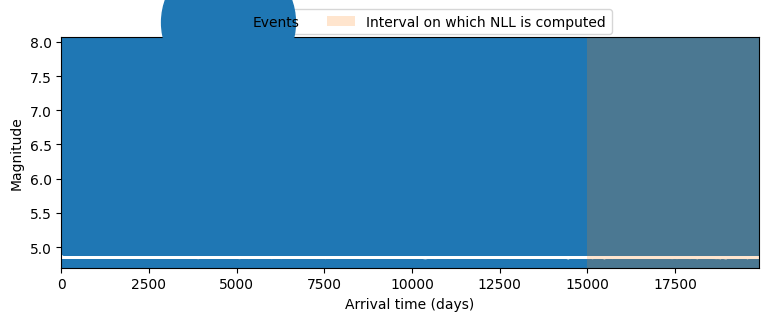

In [30]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [31]:
train_seq

Sequence(
  inter_times: [81403],
  arrival_times: [81402],
  t_start: 0.0,
  t_end: 10000.0,
  t_nll_start: 2000,
  mag: [81402],
  loc: [81402, 2],
  depth: [81402]
)

We would like to generate a 7-day forecast for the interval `[4000, 4007]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 4000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[4000, 4007]`.

In [32]:
t_forecast = 18000 # 4000 13000
duration =30   # 7
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(15000, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)
# t_forecast = 12000
# past_seq = train_seq.get_subsequence(0, t_forecast) #  3500
# observed_seq = train_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [33]:
past_seq

Sequence(
  inter_times: [16637],
  arrival_times: [16636],
  t_start: 15000.0,
  t_end: 18000.0,
  t_nll_start: 15000.0,
  mag: [16636],
  loc: [16636, 2],
  depth: [16636]
)

In [34]:
past_batch = src.data.Batch.from_list([past_seq])
# print(past_batch.inter_times)
print(past_batch.arrival_times.shape)
print(past_batch.mag.shape)
print(past_batch.input_mask.shape)

torch.Size([1, 16637])
torch.Size([1, 16637])
torch.Size([1, 16637])


In [35]:
torch.mean(past_batch.inter_times)

tensor(0.1803)

In [36]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [37]:
past_seq.float()

Sequence(
  inter_times: [16637],
  arrival_times: [16636],
  t_start: 15000.0,
  t_end: 18000.0,
  t_nll_start: 15000.0,
  mag: [16636],
  loc: [16636, 2],
  depth: [16636]
)

In [38]:
# torch.backends.cudnn.enabled = False

In [40]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 1000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[4000, 4007]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

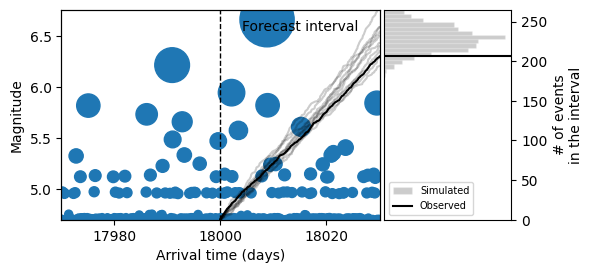

In [41]:
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [42]:
len(all_forecasts)

10000